# 01. EDA и подготовка данных

Датасет `Metro_Interstate_Traffic_Volume.csv` известен по UCI/Kaggle. Он описывает почасовой трафик на участке I-94 около Minneapolis/St Paul и погодные условия в это время.

Цель проекта - предсказывать `traffic_volume`, поэтому это задача регрессии.

In [27]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

TARGET = "traffic_volume"

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sns.set_theme(style="whitegrid", palette="Set2")

DATA_PATH = PROJECT_ROOT / "data" / "Metro_Interstate_Traffic_Volume.csv"
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "Metro_Interstate_Traffic_Volume.csv"


def load_traffic_data(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)


def clean_traffic_data(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()
    data["date_time"] = pd.to_datetime(data["date_time"], errors="coerce")
    data = data.dropna(subset=["date_time", TARGET])
    data["holiday"] = data["holiday"].fillna("None")
    data = data.drop_duplicates()
    data.loc[data["temp"] <= 1, "temp"] = np.nan
    data = data.sort_values("date_time").reset_index(drop=True)
    return data


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()
    data["hour"] = data["date_time"].dt.hour
    data["day_of_week"] = data["date_time"].dt.dayofweek
    data["month"] = data["date_time"].dt.month
    data["year"] = data["date_time"].dt.year
    data["is_weekend"] = data["day_of_week"].isin([5, 6]).astype(int)
    data["is_rush_hour"] = data["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)
    return data

## Загрузка данных

Источник для работы в проекте - локальный CSV-файл в папке `data`. В данных есть время, погода, праздники и целевая переменная `traffic_volume`.

In [28]:
raw_df = load_traffic_data(DATA_PATH)

print(f"Размер датасета: {raw_df.shape[0]} строк и {raw_df.shape[1]} колонок")
print("Колонки:", ", ".join(raw_df.columns))
display(raw_df.head())

Размер датасета: 48204 строк и 9 колонок
Колонки: holiday, temp, rain_1h, snow_1h, clouds_all, weather_main, weather_description, date_time, traffic_volume


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [29]:
column_info = pd.DataFrame(
    {
        "dtype": raw_df.dtypes.astype(str),
        "missing_count": raw_df.isna().sum(),
        "missing_share": raw_df.isna().mean().round(4),
    }
)
display(column_info)

,dtype,missing_count,missing_share
holiday,object,48143,0.9987
temp,float64,0,0.0000
rain_1h,float64,0,0.0000
snow_1h,float64,0,0.0000
clouds_all,int64,0,0.0000
weather_main,object,0,0.0000
weather_description,object,0,0.0000
date_time,object,0,0.0000
traffic_volume,int64,0,0.0000


В исходном датасете 48204 строки и 9 колонок. Почти все пропуски находятся в `holiday`: 48143 значения, то есть обычные дни без праздника. Поэтому их можно заменить на `None`.

In [30]:
duplicate_count = raw_df.duplicated().sum()
temp_anomaly_count = raw_df["temp"].le(1).sum()

print(f"Полных дубликатов: {duplicate_count}")
print(f"Подозрительных температур temp <= 1 K: {temp_anomaly_count}")
display(raw_df.loc[raw_df["temp"].le(1), ["date_time", "temp", "traffic_volume"]].head())

Полных дубликатов: 17
Подозрительных температур temp <= 1 K: 10


,date_time,temp,traffic_volume
11898,2014-01-31 03:00:00,0.0,361
11899,2014-01-31 04:00:00,0.0,734
11900,2014-01-31 05:00:00,0.0,2557
11901,2014-01-31 06:00:00,0.0,5150
11946,2014-02-02 03:00:00,0.0,291


Найдено 10 температур около 0 K. Такие значения физически невозможны для этой задачи. Я помечаю их как пропуски; в моделях они будут заполнены медианой внутри `Pipeline` только по train-части.

In [31]:
df = clean_traffic_data(raw_df)
df = add_time_features(df)

PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED_PATH, index=False)

print(f"После очистки и feature engineering: {df.shape[0]} строк и {df.shape[1]} колонок")
print(f"Колонок стало больше 10: {df.shape[1] > 10}")
display(pd.DataFrame({"missing_after_processing": df.isna().sum()}))
display(df.head())

assert df.shape[1] > 10

После очистки и feature engineering: 48187 строк и 15 колонок
Колонок стало больше 10: True


,missing_after_processing
holiday,0
temp,10
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0
hour,0


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_of_week,month,year,is_weekend,is_rush_hour
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,1,10,2012,0,1
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,1,10,2012,0,0
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,1,10,2012,0,0
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,1,10,2012,0,0
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,1,10,2012,0,0


После обработки осталось 48187 строк и 15 колонок. Удалены 17 дубликатов, `date_time` приведен к datetime, данные отсортированы по времени. Добавлены признаки `hour`, `day_of_week`, `month`, `year`, `is_weekend`, `is_rush_hour`, поэтому колонок стало больше 10.

## Распределение `traffic_volume`

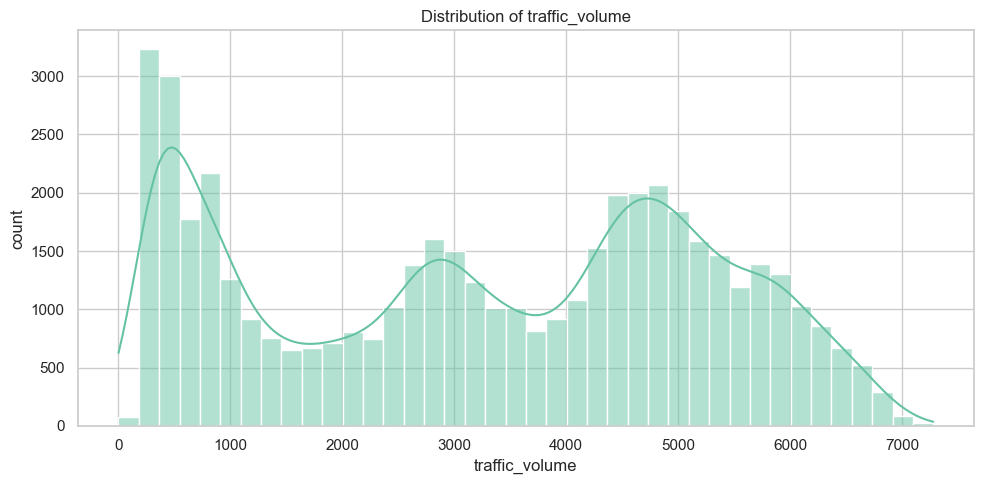

In [32]:
plt.figure(figsize=(10, 5))
sns.histplot(df["traffic_volume"], bins=40, kde=True)
plt.title("Distribution of traffic_volume")
plt.xlabel("traffic_volume")
plt.ylabel("count")
plt.tight_layout()
plt.show()

Распределение неравномерное: часто встречаются средние и высокие значения трафика, а ночью объем обычно ниже.

## `traffic_volume` по времени

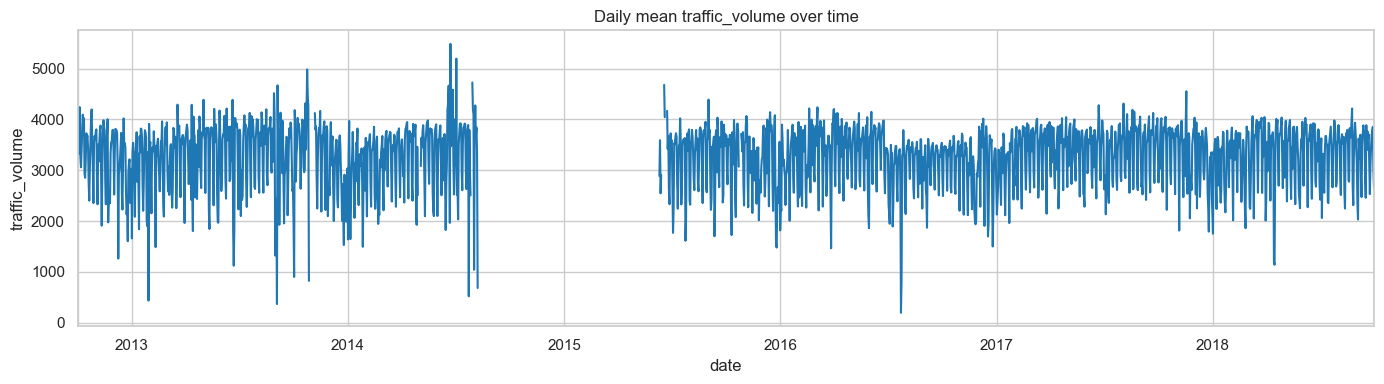

In [33]:
daily_traffic = df.set_index("date_time")["traffic_volume"].resample("D").mean()

plt.figure(figsize=(14, 4))
daily_traffic.plot(color="tab:blue")
plt.title("Daily mean traffic_volume over time")
plt.xlabel("date")
plt.ylabel("traffic_volume")
plt.tight_layout()
plt.show()

По времени видны повторяющиеся сезонные и недельные колебания. Поэтому случайный split здесь был бы рискованным.

## Средний `traffic_volume` по часу

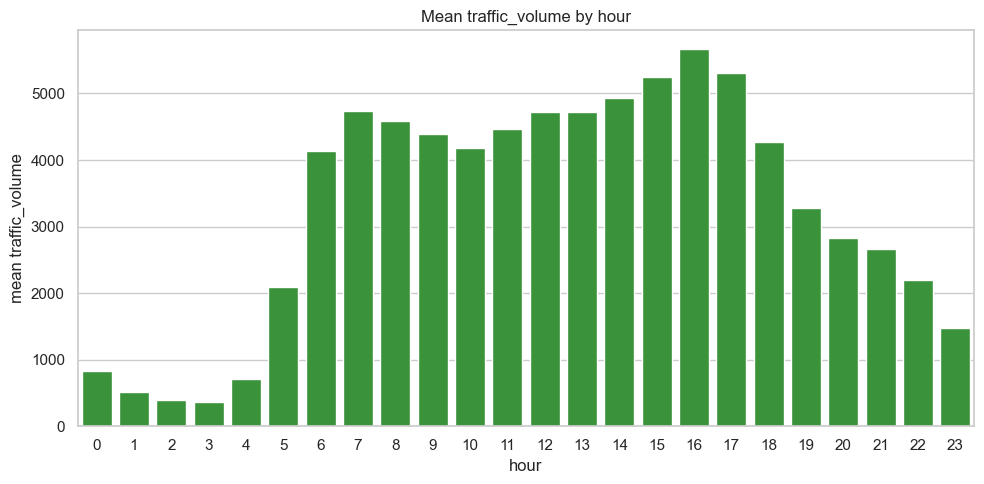

In [34]:
hourly_mean = df.groupby("hour")["traffic_volume"].mean()

plt.figure(figsize=(10, 5))
sns.barplot(x=hourly_mean.index, y=hourly_mean.values, color="tab:green")
plt.title("Mean traffic_volume by hour")
plt.xlabel("hour")
plt.ylabel("mean traffic_volume")
plt.tight_layout()
plt.show()

Трафик сильно зависит от часа. Самые высокие значения похожи на утренние и вечерние часы поездок.

## Средний `traffic_volume` по дню недели

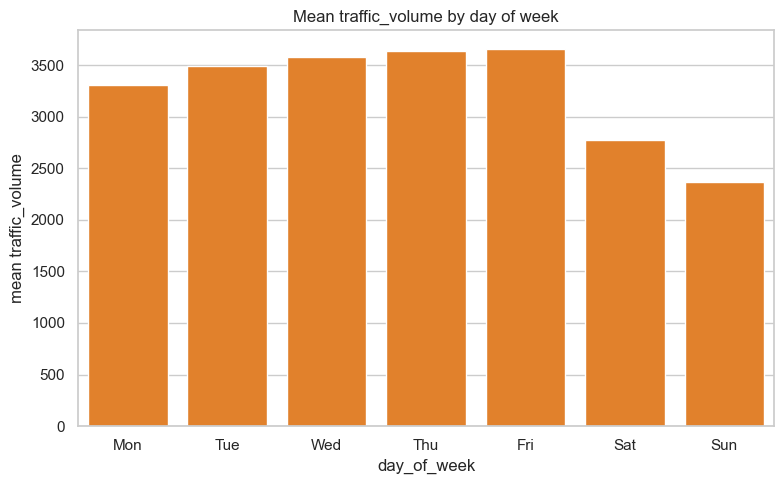

In [35]:
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_mean = df.groupby("day_of_week")["traffic_volume"].mean().reindex(range(7))

plt.figure(figsize=(8, 5))
sns.barplot(x=day_names, y=dow_mean.values, color="tab:orange")
plt.title("Mean traffic_volume by day of week")
plt.xlabel("day_of_week")
plt.ylabel("mean traffic_volume")
plt.tight_layout()
plt.show()

В будние дни средний трафик выше, чем в выходные. Признак `is_weekend` должен быть полезен.

## Средний `traffic_volume` по месяцу

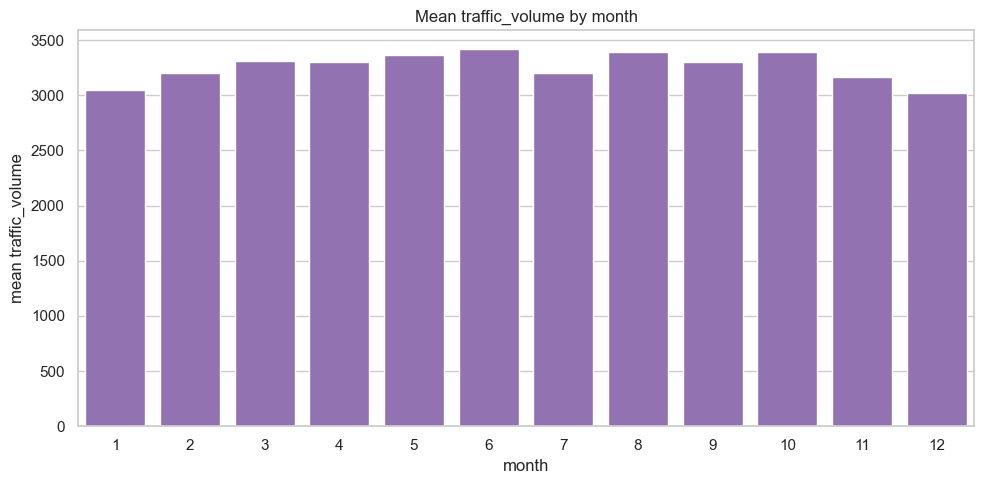

In [36]:
monthly_mean = df.groupby("month")["traffic_volume"].mean().reindex(range(1, 13))

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_mean.index, y=monthly_mean.values, color="tab:purple")
plt.title("Mean traffic_volume by month")
plt.xlabel("month")
plt.ylabel("mean traffic_volume")
plt.tight_layout()
plt.show()

Средний трафик меняется по месяцам. Это может отражать сезонность и погодные условия.

## `traffic_volume` по `weather_main`

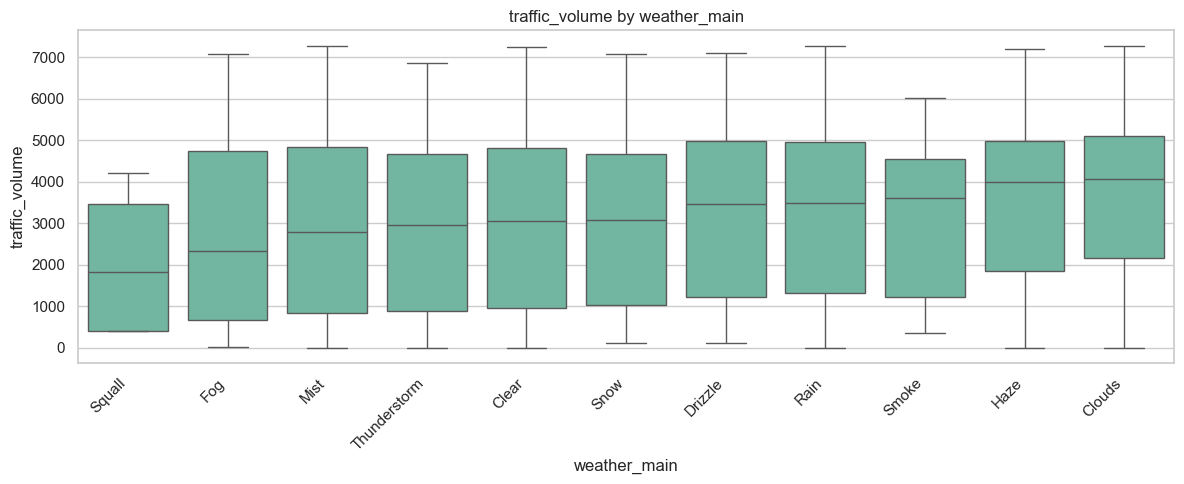

In [37]:
weather_order = df.groupby("weather_main")["traffic_volume"].median().sort_values().index

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="weather_main", y="traffic_volume", order=weather_order)
plt.title("traffic_volume by weather_main")
plt.xlabel("weather_main")
plt.ylabel("traffic_volume")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Распределения по типам погоды отличаются, но внутри каждой группы разброс большой. Одной погоды недостаточно для точного прогноза.

## Связь `temp` и `traffic_volume`

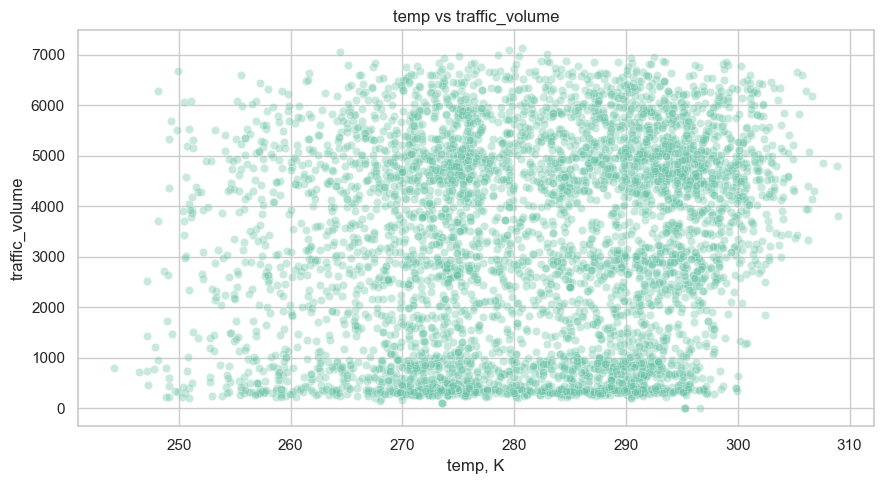

In [38]:
plt.figure(figsize=(9, 5))
sample_df = df.sample(min(5000, len(df)), random_state=42)
sns.scatterplot(data=sample_df, x="temp", y="traffic_volume", alpha=0.35)
plt.title("temp vs traffic_volume")
plt.xlabel("temp, K")
plt.ylabel("traffic_volume")
plt.tight_layout()
plt.show()

Линейной зависимости между температурой и трафиком почти не видно. Температура может помогать модели вместе с сезонными признаками.

## Correlation heatmap

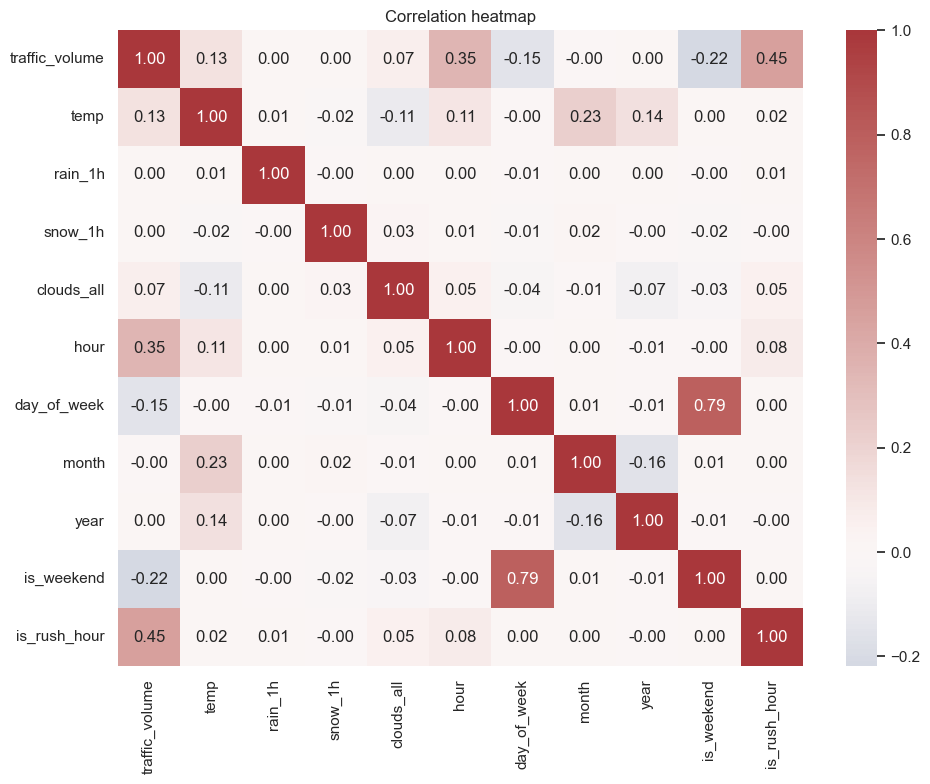

In [39]:
corr_columns = [
    "traffic_volume",
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "hour",
    "day_of_week",
    "month",
    "year",
    "is_weekend",
    "is_rush_hour",
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_columns].corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

Наиболее заметная связь у `traffic_volume` с часовыми и календарными признаками. Корреляции не описывают все зависимости, поэтому дальше сравниваются несколько моделей.